### 1D heat model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from obspy import UTCDateTime
mpl.rcParams['pdf.fonttype'] = 42

#### 0. Make an eathquake catalog
M3 events after 2018 are mostly relocated (N=683) 

Random locations are assigned for un-relocated events after 2018 

In [2]:
#Gaussian distribution for unrelocated events
def random_loc(mdist,zwid,xmed,xwid): #mdist = mdist*dx
    x = np.random.normal(loc=xmed, scale=xwid, size=1)
    z = np.random.normal(loc=mdist, scale=zwid, size=1)
    x = (np.round(x).astype(int))/1000
    z = (np.round(z).astype(int))/1000
    return x[0],z[0]

In [3]:
#define the reference point (the top of profile)
lon_ref=0.25
lat_ref=0.5
dep_ref=148.25

#import M3 relocated catalog
reloc_M3=pd.read_csv('data/reloc_M3_683_eqs_rlon_{}_rlat_{}_rdep_{}.csv'.format(lon_ref,lat_ref,dep_ref))

#import all events after 2018
catalog_all = pd.read_csv('data/catalog_fmf_16templates.csv', usecols=[0,2,5,34], skiprows=1, header=None, names=['time','tempid','evid','mag'])
catalog_all = catalog_all[catalog_all['mag']>0]
catalog_all = catalog_all[catalog_all['time']>UTCDateTime('2018-01-01T00:00:00')]
reloc_index = catalog_all['evid'].isin(reloc_M3['evid']).astype(int).tolist()
catalog_all['reloc']=reloc_index

#import the mean location data
centroids=pd.read_csv('data/centroids_rlon_{}_rlat_{}_rdep_{}.csv'.format(lon_ref,lat_ref,dep_ref), usecols=[0,4])

#the second template doesn't have any successful relocated event, so we assigned the mean distance that is calculated by the mean of 1st and 3rd template
mdist_39307=((centroids[centroids['tempid']=='SGC2018yyczk_34942']['mdist'].iloc[0]+centroids[centroids['tempid']=='SGC2018yyczk_45482']['mdist'].iloc[0])/2)
centroids.loc[centroids.index[1],'mdist']=mdist_39307

In [4]:
zwid = 200; xwid = 100; xmed=250 # mdist: mean of z,  zwid: sigma_1 of z, xmed: mean of x xwid: sigma_1 of x
r = []; rx = []
for i in range(len(catalog_all)):
    tempid = catalog_all['tempid'].iloc[i]
    reloc_idx = catalog_all['reloc'].iloc[i]
    evid = catalog_all['evid'].iloc[i]
    
    if reloc_idx == 0:
        mdist  = centroids[centroids['tempid']==tempid]['mdist'].iloc[0]
        mdist = mdist*10**3 #unit conversion [m]
        x,z    = random_loc(mdist,zwid,xmed,xwid) #The output is km scale!
    else:
        x = reloc_M3[reloc_M3['evid']==evid]['x'].iloc[0]
        z = reloc_M3[reloc_M3['evid']==evid]['z'].iloc[0]        

    r.append(z)
    rx.append(x)

catalog_all['x']=rx
catalog_all['z']=r

catalog_all.to_csv('data/hypo_catalog_1D_model.csv', index=None)

#### 1. Import earthquake catalog with their locations in the modeling domain

In [5]:
catalog=pd.read_csv('data/hypo_catalog_1D_model.csv') #catalog used in Fig. 4
catalog['time'] = pd.to_datetime(catalog['time'], utc=True)

#catalog=catalog[(catalog['x']>0.05) & (catalog['x']<0.2)]
#catalog=catalog[catalog['x']<0.2]
#catalog=catalog.reset_index(drop=True)
print('N={} of 22823 are used ({}%)'.format(len(catalog),100*len(catalog)/22823))

#------------------------------------
# Making color map from template ids
#------------------------------------
temp_list = pd.read_csv('catalog_16subtemplates_R1.csv')
cm = mpl.colormaps.get_cmap('coolwarm')
cmap = []; colors=[]
for idx in range(len(temp_list)-1,-1,-1):
    cmap.append(cm(idx/len(temp_list))) #reversed coolwarm

#------------------------------------
# Assigning colors for each event
#------------------------------------
for tempid in catalog['tempid']:
    idx = temp_list[temp_list['tempid']==tempid].index[0]
    colors.append(cmap[idx])
catalog['color']=colors

temp_index_list=catalog[catalog['evid'].isin(temp_list['Event No'])].index.tolist()

N=22823 of 22823 are used (100.0%)


Text(0.5, 0, 'Event count')

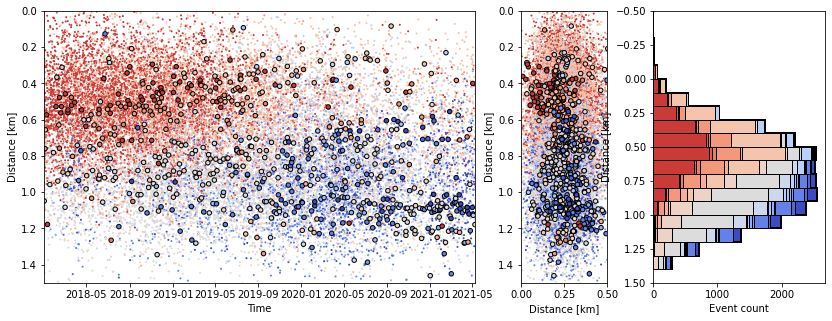

In [6]:
# Size of matrices, create matrices
nz = 1500 #unit: m   
nx = 250 #unit: m

catalog_reloc=catalog[catalog['reloc']==1] #M>3 events (relocated)
catalog_random=catalog[catalog['reloc']==0] # un-relocated events (random locations)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(14, 5),gridspec_kw={'width_ratios': [5, 1, 2]})

ax1.scatter(catalog_random['time'], catalog_random['z'],s=1,c=catalog_random['color'])
ax1.scatter(catalog_reloc['time'],catalog_reloc['z'],s=20,c=catalog_reloc['color'],edgecolor='k')
ax1.set_xlabel('Time'); ax1.set_ylabel('Distance [km]')
ax1.set_ylim([0,1.5])
ax1.invert_yaxis()
ax1.margins(x=0)

ax2.scatter(catalog_random['x'],catalog_random['z'],s=1,c=catalog_random['color'])
ax2.scatter(catalog_reloc['x'],catalog_reloc['z'],s=20,c=catalog_reloc['color'],edgecolor='k')
ax2.set_xlim([0,0.5]); ax2.set_ylim([0,1.5])
ax2.set_xlabel('Distance [km]'); ax2.set_ylabel('Distance [km]')
ax2.invert_yaxis()

data_reloc=catalog_reloc[catalog_reloc['z']<=1.5]
data_random=catalog_random[catalog_random['z']<=1.5]

for i,tempid in enumerate(temp_list['tempid']):
    data_random_temp=data_random[data_random['tempid']==tempid]
    data_reloc_temp=data_reloc[data_reloc['tempid']==tempid]
    c_edge=cmap[i]
    
    df=pd.concat([data_random_temp, data_reloc_temp])
    if i == 0:
        df_sum = df
    else:    
        df_sum=pd.concat([df, df_sum])
    
    ax3.hist(df_sum['z'], bins=np.arange(-0.5,1.5,0.1), orientation='horizontal', facecolor=c_edge, edgecolor='k', linewidth=1, zorder=len(temp_list) - i)

df=pd.concat([data_random, data_reloc])
ax3.hist(df['z'], bins=np.arange(-0.5,1.5,0.1), orientation='horizontal', facecolor='none', edgecolor='k', linewidth=2)
ax3.set_ylim([-0.5,1.5])
ax3.invert_yaxis()
ax3.set_ylabel('Distance [km]')
ax3.set_xlabel('Event count')

#plt.savefig('pdf/Figure_event_distribution.pdf')

#### 2. Calculate rupture-induced heating

In [7]:
myu = 6.62*10**10       # shear modulus [Pa] from Prieto et al. (2013)
stress_drop = 30*10**6  # stress drop [10 MPa] assumed for all earthquakes [10 MPa]
G_slope = 10**8         #slope of intermediate-depth earthquakes in Figure 3 (Prieto et al., 2013)

#--------------------------------------------------------
moment_mag = 0.958*catalog['mag']+0.1 #SGC mag to moment mag
moment = 10.**(1.5*moment_mag+9.1) #Hanks and Kanamori (1979)

radius  = np.cbrt((7.*moment)/(16.*stress_drop)) #Eshelby's circular crack model
area    = np.pi*(radius**2.) # fault area: A = r^2 * pi [m^2]
slip    = stress_drop*(16.*radius)/(7.*myu*np.pi) # slip [m]
#--------------------------------------------------------

C       = 1                # heat capacity from Prieto et al., 2013 [J/(g*degree of C)]
density = 3360*10**3       # density of the slab [g/m^3]
G       = G_slope*slip**2  # earthquake fracture energy per unit area
swid    = [0.01,0.003,0.001] # fault width [m]
Q       = G*np.pi*radius**2

S_T_array     = np.zeros((len(swid),len(G)))
for i,width in enumerate(swid): 
    S_T_array[i,] = G/(C*density*width)

#### Magnitude vs temperature across three fault widths

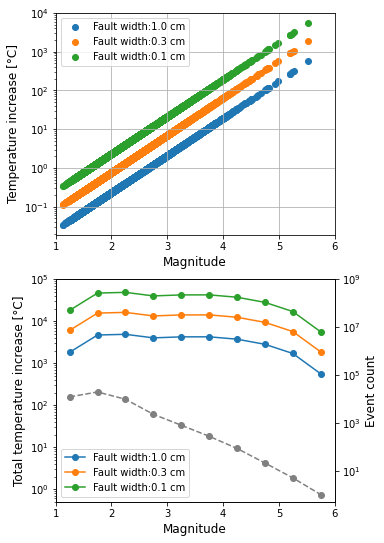

In [8]:
fig, (ax,ax1) = plt.subplots(2, 1,figsize=(5, 9))

for i in range(S_T_array.shape[0]):
    ax.scatter(catalog['mag'], S_T_array[i,], label='Fault width:{} cm'.format(swid[i]*10**2))
ax.set_xlim([1,6])
ax.set_yscale('log')
ax.set_xlabel('Magnitude', fontsize=12)
ax.set_ylabel('Temperature increase [°C]', fontsize=12)
ax.grid()
ax.legend()

sum_temp=np.zeros((3,12)); num_mag=np.zeros((12))
for mag in range(12):
    min_mag = 0.5*mag
    max_mag = 0.5*mag+1
    index_array=catalog[(catalog['mag']>min_mag) & (catalog['mag']<=max_mag)].index
    sum_temp[0,mag] = np.sum(S_T_array[0,index_array]) #fault thickness: 10 mm
    sum_temp[1,mag] = np.sum(S_T_array[1,index_array]) #fault thickness: 3 mm
    sum_temp[2,mag] = np.sum(S_T_array[2,index_array]) #fault thickness: 1 mm
    num_mag[mag] = len(index_array)
    
for i in range(S_T_array.shape[0]):
    ax1.plot(np.arange(2,12)/2+0.25,sum_temp[i,2:],marker='o',label='Fault width:{} cm'.format(swid[i]*10**2))
ax1.set_ylim([0.5,10**5])
ax1.set_ylabel('Total temperature increase [°C]', fontsize=12)
ax1.set_xlabel('Magnitude', fontsize=12)
ax1.set_yscale('log')
plt.legend()

ax2=ax1.twinx()
ax2.plot(np.arange(2,12)/2+0.25,num_mag[2:],marker='o',c='gray', linestyle='--')
ax2.set_ylim([0.5,10**9])
ax2.set_ylabel('Event count', fontsize=12)
ax2.set_yscale('log')
ax2.set_xlim([1,6])

plt.show()

#### Expected fracture energy release across magnitudes

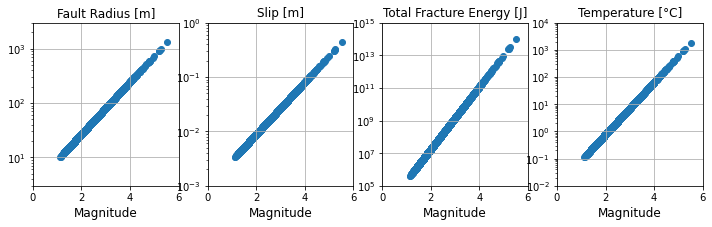

In [9]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4,figsize=(12, 3))

#Fault Radius
ax1.scatter(catalog['mag'],radius)
ax1.set_xlim([0,6]); ax1.set_ylim([3,3000])
ax1.set_yscale('log')
ax1.set_xlabel('Magnitude', fontsize=12)
ax1.set_title('Fault Radius [m]', fontsize=12)
ax1.grid()

#Slip
ax2.scatter(catalog['mag'],slip)
ax2.set_xlim([0,6]); ax2.set_ylim([0.001,1])
ax2.set_yscale('log')
ax2.set_xlabel('Magnitude', fontsize=12)
ax2.set_title('Slip [m]', fontsize=12)
ax2.grid()

#fracture energy
ax3.scatter(catalog['mag'],Q)
ax3.set_xlim([0,6]); ax3.set_ylim([10**5,10**15])
ax3.set_yscale('log')
ax3.set_xlabel('Magnitude', fontsize=12)
ax3.set_title('Total Fracture Energy [J]', fontsize=12)
ax3.grid()

#temperature
ax4.scatter(catalog['mag'],S_T_array[1,])
ax4.set_xlim([0,6]); ax4.set_ylim([10**(-2),10**4])
ax4.set_yscale('log')
ax4.set_xlabel('Magnitude', fontsize=12)
ax4.set_title('Temperature [°C]', fontsize=12)
ax4.grid()

#### Thermal diffusing time scales

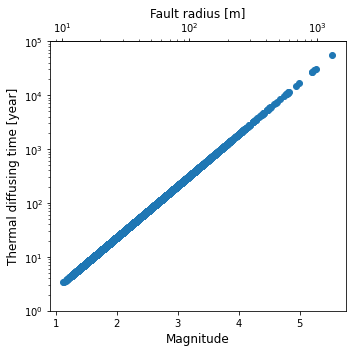

In [10]:
kappa=10**(-6)

fig, ax1 = plt.subplots(1, 1,figsize=(5, 5))
ax1.scatter(catalog['mag'], radius**2/kappa/(60*60*24*365))
ax1.set_yscale('log')
ax1.set_ylim([1,10**5])
ax1.set_xlabel('Magnitude',  fontsize=12)
ax1.set_ylabel('Thermal diffusing time [year]',  fontsize=12)

def mag2rad(mag):    
    stress_drop = 30*10**6  # stress drop [10 MPa] assumed for all earthquakes [10 MPa]

    moment_mag = 0.958*mag+0.1 #SGC mag to moment mag
    moment = 10.**(1.5*moment_mag+9.1) #Hanks and Kanamori (1979)
    radius  = np.cbrt((7.*moment)/(16.*stress_drop)) #Eshelby's circular crack model
    
    return radius

def rad2mag(radius):
    stress_drop = 30*10**6
    moment = (16.*stress_drop*radius**3)/7 
    moment_mag = (np.log10(moment)-9.1)/1.5
    mag = (moment_mag-0.1)/0.958 
    
    return mag

secax = ax1.secondary_xaxis('top', functions=(mag2rad, rad2mag))
#secax.plot(Q_bin,np.arange(int(len_z/bw))*bw,c='k')
secax.set_xlabel('Fault radius [m]', fontsize=12)
secax.set_xscale('log')

fig.tight_layout()
#plt.savefig('pdf/FigureS14.pdf')
#plt.show()


#### 3. Assigning Q into the volume cylinder

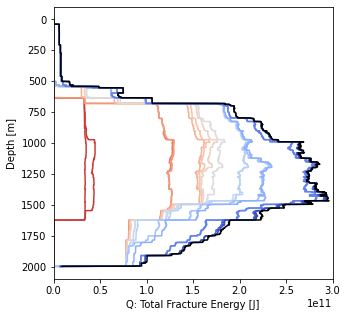

In [15]:
len_z = 2000 #the total length of z-axis [m]
ref_z = 500 #the reference point where the migration starts in z-axis [m] 

z_vol = np.zeros((len_z))
z_vol_time = np.zeros((len(catalog),len_z))

fig, ax1 = plt.subplots(1, 1,figsize=(5, 5))
for i in range(len(catalog)):
    z = catalog['z'].iloc[i]*1000 + ref_z
    l_scale = radius[i] 
    z_min = int(z - l_scale/2)
    z_max = int(z + l_scale/2)
    #print(z_min,z,z_max,catalog['mag'].iloc[i])
    Q_z = Q[i]/int(z_max - z_min)
    z_vol[z_min:z_max] += Q_z
    z_vol_time[i,:] = z_vol
    
    if i in temp_index_list:
        ax1.plot(z_vol,np.arange(len_z),c=catalog['color'].iloc[i])

ax1.plot(z_vol,np.arange(len_z),c='k')
ax1.set_xlim([0,3*10**11])
ax1.set_xlabel('Q: Total Fracture Energy [J]')
ax1.set_ylabel('Depth [m]')
plt.gca().invert_yaxis()
plt.show()

#### 4. Calculating temperature

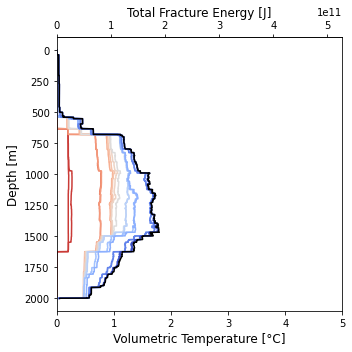

In [16]:
rc = 125 #radius of the cylinder [m]
#r1 = 50; r2 = 200 #doughnut [m]
#rc = np.sqrt((r2**2 - r1**2))
bw = 1 #bin width
tbw = 2000 #event bin (time step to show the figure: plot after every tbw-th events)
Q_bin = np.zeros((int(len_z/bw)))
dT = np.zeros((int(len_z/bw)))

fig, ax1 = plt.subplots(1, 1,figsize=(5, 5))
#ax2 = ax1.twiny()

#for t_bin in range(int(len(catalog)/tbw)):
for t in temp_index_list:
    for z_bin in range(int(len_z/bw)):
        #Q_bin[z_bin] = np.sum(z_vol_time[t_bin*tbw,z_bin*bw:z_bin*bw+bw]) #total energy per bin
        Q_bin[z_bin] = np.sum(z_vol_time[t,z_bin*bw:z_bin*bw+bw]) #total energy per bin
        dT[z_bin] = Q_bin[z_bin]/(C*density*np.pi*rc**2*bw)

    #Total Fracture Energy plot    
    #ax2.plot(Q_bin,np.arange(int(len_z/bw))*bw,c=catalog['color'].iloc[t])
    
    #Temperature plot
    ax1.plot(dT,np.arange(int(len_z/bw))*bw,c=catalog['color'].iloc[t])

for z_bin in range(int(len_z/bw)):
    Q_bin[z_bin] = np.sum(z_vol_time[-1,z_bin*bw:z_bin*bw+bw]) #total energy per bin
    dT[z_bin] = Q_bin[z_bin]/(C*density*np.pi*rc**2*bw)    
    
ax1.plot(dT,np.arange(int(len_z/bw))*bw,c='k')
ax1.set_xlabel('Volumetric Temperature [°C]', fontsize=12) 
ax1.set_xlim([0,5.0])
ax1.set_ylabel('Depth [m]', fontsize=12)

def temp2eng(dT):
    C       = 1                # heat capacity from Prieto et al., 2013 [J/(g*degree of C)]
    density = 3360*10**3       # density of the slab [g/m^3]
    rc   = 100 
    Q = dT*(C*density*np.pi*rc**2)
    
    return Q

def eng2temp(Q):    
    C       = 1                # heat capacity from Prieto et al., 2013 [J/(g*degree of C)]
    density = 3360*10**3       # density of the slab [g/m^3]
    rc   = 100 
    dT = Q/(C*density*np.pi*rc**2)
    
    return dT

secax = ax1.secondary_xaxis('top', functions=(temp2eng, eng2temp))
#secax.plot(Q_bin,np.arange(int(len_z/bw))*bw,c='k')
secax.set_xlabel('Total Fracture Energy [J]', fontsize=12)

fig.tight_layout()
ax1.invert_yaxis()
plt.show()
#plt.savefig('Figure4/Volumetric_temperature.pdf')

#### 5. Local temperature increase

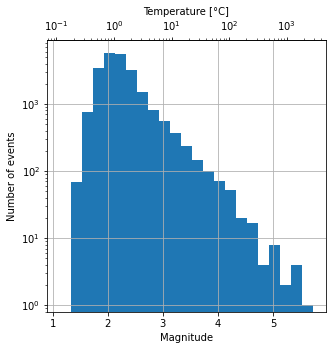

In [17]:
fig, ax1 = plt.subplots(1, 1,figsize=(5, 5))

#counts, bins = np.histogram(S_T_array[1,], bins=np.arange(0,np.max(S_T_array[1,])+50,50))
#counts, bins = np.histogram(S_T_array[1,], bins=np.logspace(np.log10(np.min(S_T_array[1,])),np.log10(np.max(S_T_array[1,])),num=50))
counts, bins = np.histogram(catalog['mag'], bins=np.arange(np.min(catalog['mag']),np.max(catalog['mag'])+0.2,0.2))
ax1.hist(bins[1:], bins, weights=counts)
#ax1.plot(bins[1:],counts)
ax1.set_yscale('log')
ax1.set_xlabel('Magnitude')
ax1.set_ylabel('Number of events')

def mag2temp(mag):
    myu = 6.62*10**10       # shear modulus [Pa] from Prieto et al. (2013)
    stress_drop = 30*10**6  # stress drop [10 MPa] assumed for all earthquakes [10 MPa]
    G_slope = 10**8         #slope of intermediate-depth earthquakes in Figure 3 (Prieto et al., 2013)
    
    moment_mag = 0.958*mag+0.1 #SGC mag to moment mag
    moment = 10.**(1.5*moment_mag+9.1) #Hanks and Kanamori (1979)

    radius  = np.cbrt((7.*moment)/(16.*stress_drop)) #Eshelby's circular crack model
    area    = np.pi*(radius**2.) # fault area: A = r^2 * pi [m^2]
    slip    = stress_drop*(16.*radius)/(7.*myu*np.pi) # slip [m]
    G       = G_slope*slip**2  # earthquake fracture energy per unit area
    Q       = G*np.pi*radius**2

    C       = 1                # heat capacity from Prieto et al., 2013 [J/(g*degree of C)]
    density = 3360*10**3       # density of the slab [g/m^3]
    width   = 0.003 #3 mm
    
    T       = G/(C*density*width)
    
    return T 

def temp2mag(T):
    myu = 6.62*10**10       # shear modulus [Pa] from Prieto et al. (2013)
    stress_drop = 30*10**6  # stress drop [10 MPa] assumed for all earthquakes [10 MPa]
    G_slope = 10**8         #slope of intermediate-depth earthquakes in Figure 3 (Prieto et al., 2013)
    
    C       = 1                # heat capacity from Prieto et al., 2013 [J/(g*degree of C)]
    density = 3360*10**3       # density of the slab [g/m^3]
    width   = 0.003 #3 mm
    
    G       = T*(C*density*width)
    slip    = np.sqrt(G/G_slope)
    radius  = (7.*myu*np.pi)*slip/(16*stress_drop)
    moment  = 16*stress_drop*radius**3/7
    moment_mag = (np.log10(moment)-9.1)/1.5
    mag     = (moment_mag - 0.1)/0.958

    return mag

secax = ax1.secondary_xaxis('top', functions=(mag2temp, temp2mag))
secax.set_xlabel('Temperature [°C]')
secax.set_xscale('log')
ax1.set_ylim(0.8, None)
ax1.axhline(0.1, alpha=0)
plt.grid()
plt.show()

#plt.savefig('Figure4/mag_vs_temp_vs_numbers.pdf')

#### 6. Mantle Energy Budget

In [18]:
catalog_buca=pd.read_csv('catalog_main_13stat_M3_comb.csv')

myu = 6.62*10**10       # shear modulus [Pa] from Prieto et al. (2013)
stress_drop = 30*10**6  # stress drop [10 MPa] assumed for all earthquakes [10 MPa]
G_slope = 10**8         #slope of intermediate-depth earthquakes in Figure 3 (Prieto et al., 2013)

moment_mag = 0.958*catalog_buca['median Mi']+0.1 #SGC mag to moment mag
moment = 10.**(1.5*moment_mag+9.1) #Hanks and Kanamori (1979)

radius  = np.cbrt((7.*moment)/(16.*stress_drop)) #Eshelby's circular crack model
area    = np.pi*(radius**2.) # fault area: A = r^2 * pi [m^2]
slip    = stress_drop*(16.*radius)/(7.*myu*np.pi) # slip [m]
#--------------------------------------------------------

C       = 1                # heat capacity from Prieto et al., 2013 [J/(g*degree of C)]
density = 3360*10**3       # density of the slab [g/m^3]: 3.36 kg/m^3
G       = G_slope*slip**2  # earthquake fracture energy per unit area
swid    = [0.01,0.003,0.001] # fault width [m]
Q       = G*np.pi*radius**2

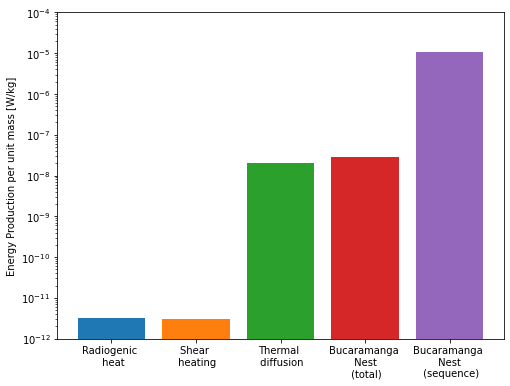

In [28]:
radio_w = 13*10**12 #energy budget [J/s]
radio_m = 4*10**24 #entire mantle mass[kg]
radio_wm = radio_w/radio_m

diff_t = (10**3)**2/kappa #1 km diffusing time scale
diff_T_t = 20/diff_t # 20 K gradient over 1 km
diff_wm = C*1000*diff_T_t

buca_w = np.sum(Q)/((3+5/12+10/31)*365*24*60*60)
buca_m = 5000**3*density/1000 #mass of 5-km cube [kg]
buca_wm = buca_w/buca_m

family_w = np.sum(z_vol)/((3+5/12+10/31)*365*24*60*60) #all fracture energy [J] in the cylinder
#family_m = rc**2*np.pi*len_z*density #mass of cylinder [kg]
family_m = rc**2*np.pi*1500*density/1000 #mass of cylinder [kg]
family_wm = family_w/family_m

fig, ax = plt.subplots(1, 1,figsize=(8, 6))
ax.bar('Radiogenic \n heat', radio_wm, align='center')
ax.bar('Shear \n heating', 10**(-8)/3360, align='center')
ax.bar('Thermal \n diffusion', diff_wm, align='center')
ax.bar('Bucaramanga \n Nest \n (total)', buca_wm, align='center')
ax.bar('Bucaramanga \n Nest \n (sequence)', family_wm, align='center')
ax.set_ylabel('Energy Production per unit mass [W/kg]')
ax.set_yscale('log')
ax.set_ylim([10**(-12),10**(-4)])
plt.show()
#plt.savefig('Figure4/mantle_energy_budgets.pdf')